**Importing the Libraries**

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Importing the Dataset**

In [12]:
dataset = pd.read_csv('Telco-Customer-Churn_Dataset.csv')
X = dataset.drop('Churn', axis=1)
y = dataset['Churn']


**Take Care of Missing Values**

In [13]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())
if 'customerID' in dataset.columns:
    dataset = dataset.drop('customerID', axis=1)

**One-Hot Encoding Categorical Data**

In [17]:
X = dataset.drop('Churn', axis=1)
categorical_cols = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)




In [18]:
print(X)

[[0.0000e+00 1.0000e+00 0.0000e+00 ... 1.0000e+00 2.9850e+01 2.9850e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 3.4000e+01 5.6950e+01 1.8895e+03]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 1.1000e+01 2.9600e+01 3.4645e+02]
 [1.0000e+00 1.0000e+00 0.0000e+00 ... 4.0000e+00 7.4400e+01 3.0660e+02]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 6.6000e+01 1.0565e+02 6.8445e+03]]


In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)  # Yes=1, No=0

In [20]:
print(y)

[0 0 1 ... 0 1 0]


**Splitting Dataset into Training and Test Set**

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:
print(X_train)

[[0.00000e+00 0.00000e+00 1.00000e+00 ... 2.10000e+01 6.48500e+01
  1.33680e+03]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 5.40000e+01 9.72000e+01
  5.12945e+03]
 [1.00000e+00 1.00000e+00 0.00000e+00 ... 1.00000e+00 2.34500e+01
  2.34500e+01]
 ...
 [1.00000e+00 1.00000e+00 1.00000e+00 ... 1.20000e+01 2.11500e+01
  3.06050e+02]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 1.20000e+01 9.94500e+01
  1.20015e+03]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 2.60000e+01 1.98000e+01
  4.57300e+02]]


In [23]:
print(X_test)

[[0.0000e+00 1.0000e+00 0.0000e+00 ... 1.0000e+00 2.4800e+01 2.4800e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 4.1000e+01 2.5250e+01 9.9645e+02]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 5.2000e+01 1.9350e+01 1.0317e+03]
 ...
 [1.0000e+00 1.0000e+00 1.0000e+00 ... 1.7000e+01 1.9900e+01 3.2975e+02]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 6.9000e+01 4.3950e+01 2.9601e+03]
 [1.0000e+00 0.0000e+00 1.0000e+00 ... 1.0000e+00 3.1350e+01 3.1350e+01]]


In [24]:
print(y_train)

[0 0 1 ... 0 1 0]


In [25]:
print(y_test)

[1 0 0 ... 0 0 1]


**Feature Scaling**

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [27]:
print(X_train)

[[-1.02516569e+00 -9.69578591e-01  1.53218588e+00 ... -4.65683364e-01
  -4.73723375e-04 -4.21345130e-01]
 [-1.02516569e+00 -9.69578591e-01 -6.52662324e-01 ...  8.85536787e-01
   1.07475386e+00  1.25588791e+00]
 [ 9.75452077e-01  1.03137591e+00 -6.52662324e-01 ... -1.28460467e+00
  -1.37649913e+00 -1.00215117e+00]
 ...
 [ 9.75452077e-01  1.03137591e+00  1.53218588e+00 ... -8.34197950e-01
  -1.45294499e+00 -8.77176266e-01]
 [ 9.75452077e-01 -9.69578591e-01 -6.52662324e-01 ... -8.34197950e-01
   1.14953785e+00 -4.81776199e-01]
 [ 9.75452077e-01 -9.69578591e-01 -6.52662324e-01 ... -2.60953038e-01
  -1.49781538e+00 -8.10288602e-01]]


In [28]:
print(X_test)

[[-1.02516569  1.03137591 -0.65266232 ... -1.28460467 -1.33162874
  -1.00155415]
 [ 0.97545208 -0.96957859 -0.65266232 ...  0.35323794 -1.31667194
  -0.57185896]
 [-1.02516569  1.03137591  1.53218588 ...  0.80364466 -1.51277218
  -0.55627026]
 ...
 [ 0.97545208  1.03137591  1.53218588 ... -0.62946762 -1.49449165
  -0.86669536]
 [-1.02516569  1.03137591  1.53218588 ...  1.49972776 -0.69513389
   0.29653087]
 [ 0.97545208 -0.96957859  1.53218588 ... -1.28460467 -1.11392424
  -0.99865753]]


In [29]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

**Building the XGBoost Model**

In [30]:
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**Testing Model on the Test Set**

In [31]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[1 1]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [1 1]]


**Making Confusion Matrix**

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[897 139]
 [145 228]]


0.7984386089425124

**K-Folds Cross Validation**

In [33]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 84.45 %
Standard Deviation: 8.66 %


In [34]:

from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.7, 0.8, 0.9, 1]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator= classifier,
    param_distributions=params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Train
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_model = random_search.best_estimator_

# Predictions
y_prob = best_model.predict_proba(X_test)[:,1]

# LOWER threshold
y_pred_new = (y_prob > 0.3).astype(int)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [35]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred))

Accuracy: 0.7984386089425124
ROC-AUC: 0.849525655490803
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1036
           1       0.62      0.61      0.62       373

    accuracy                           0.80      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409



**Visualizing the Results**

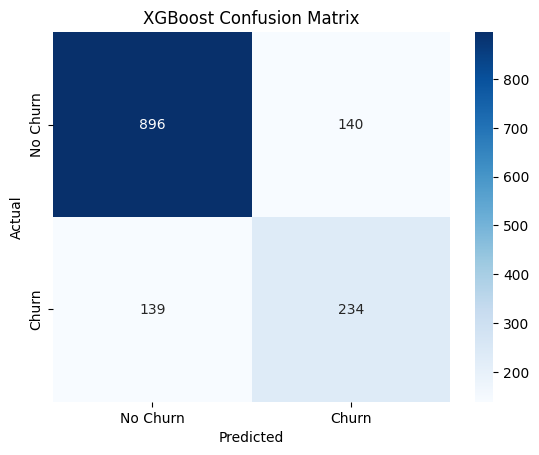

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

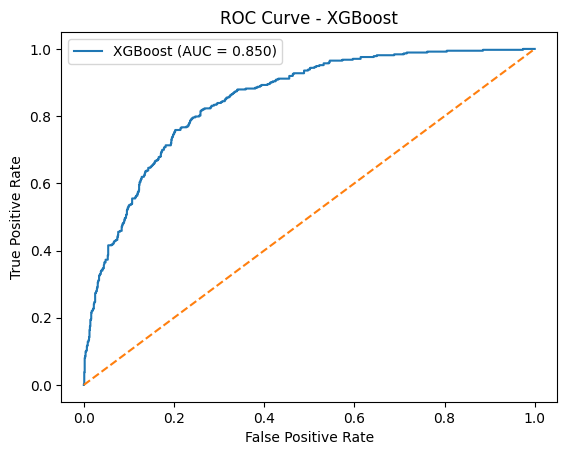

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="XGBoost (AUC = %.3f)" % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

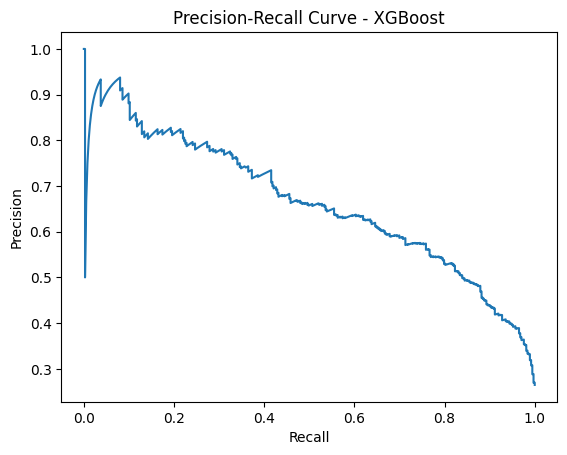

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

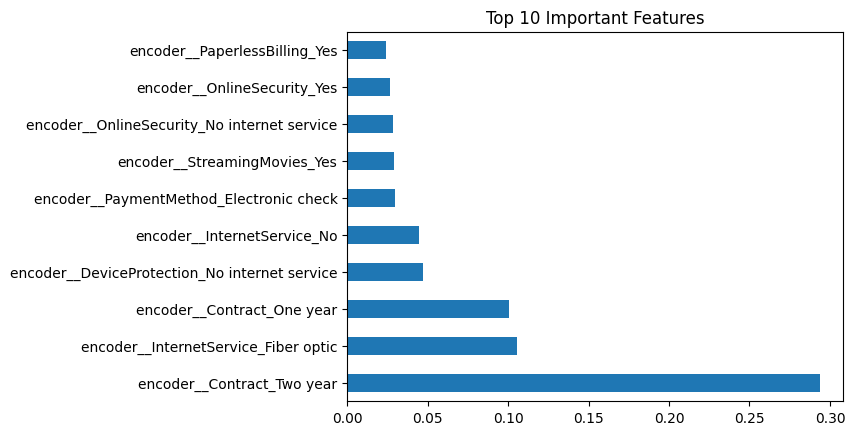

In [40]:
import pandas as pd

importances = best_model.feature_importances_

# Create feature names (after encoding)
feature_names = ct.get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()